# Early Fusion Method

In [1]:
# --- 1. Basic Utilities ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 2. TensorFlow & Keras ---
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# --- 3. Evaluation Metrics ---
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix

2026-04-06 03:39:45.851132: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775446786.039647      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775446786.096581      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775446786.537811      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775446786.537858      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775446786.537861      24 computation_placer.cc:177] computation placer alr

In [2]:
import os
import random
from pathlib import Path
from PIL import Image
from tensorflow.keras import layers
import tensorflow as tf

# 1. Configuration
input_root = "/kaggle/input/datasets/hossamfakher/cxr-ct-cough/processed_dataset/processed_dataset"
output_root = "/kaggle/working/processed_dataset_split"
splits = {'train': 400, 'valid': 50, 'test': 50}
modalities = ["CT", "CXR", "Cough sound"]
classes = ["Healthy", "Lungs Cancer", "Pneumonia", "covid"]
IMG_SIZE = (224, 224)

# تثبيت الـ Seed لضمان إن الـ Shuffle يكون متطابق لكل الـ Modalities
random.seed(42)

# 2. Create output directories
for split in splits:
    for modality in modalities:
        for cls in classes:
            os.makedirs(os.path.join(output_root, split, modality, cls.replace(" ", "")), exist_ok=True)

# 3. Process Classes
for cls in classes:
    cls_clean = cls.replace(" ", "")
    
    # نجيب لستة الصور لكل Modality للـ Class الحالي
    modality_files = {}
    for mod in modalities:
        folder = os.path.join(input_root, mod, cls_clean)
        # بنرتبهم أبجدياً الأول عشان نضمن إن Index 0 في الكل هو نفس البداية (لو التسمية الأصلية موحدة)
        files = sorted(list(Path(folder).glob("*.[jp][pn]g")))
        modality_files[mod] = files

    # التأكد من أن عدد الصور متساوي في الـ 3 modalities للـ Class ده
    min_len = min(len(modality_files[m]) for m in modalities)
    if min_len < sum(splits.values()):
        print(f"⚠️ Warning: Class {cls} has only {min_len} aligned samples.")
    
    # عمل Shuffle للـ Indices (مش للملفات نفسها) عشان نضمن التزامن
    indices = list(range(min_len))
    random.shuffle(indices)

    # تقسيم الـ Indices حسب الـ Splits
    split_indices = {
        'train': indices[:splits['train']],
        'valid': indices[splits['train']:splits['train'] + splits['valid']],
        'test': indices[splits['train'] + splits['valid']:splits['train'] + splits['valid'] + splits['test']]
    }

    # 4. Save & Resize
    for split, idx_list in split_indices.items():
        for i, idx in enumerate(idx_list, 1):
            for mod in modalities:
                img_path = modality_files[mod][idx]
                
                # فتح الصورة، تحويلها لـ RGB، وعمل الـ Resize
                img = Image.open(img_path).convert("RGB")
                img = img.resize(IMG_SIZE, Image.Resampling.LANCZOS)
                
                # تسمية موحدة (مثلاً Healthy_Sample1.jpg) في الـ 3 folders
                new_name = f"{cls_clean}_Sample{i}.jpg"
                save_path = os.path.join(output_root, split, mod, cls_clean, new_name)
                img.save(save_path)
                
    print(f"✅ Finished processing class: {cls}")

print("\n🚀 All data is synchronized, resized, and split!")

✅ Finished processing class: Healthy
✅ Finished processing class: Lungs Cancer
✅ Finished processing class: Pneumonia
✅ Finished processing class: covid

🚀 All data is synchronized, resized, and split!


In [3]:
from tensorflow.keras import regularizers
from tensorflow.keras import layers , models
import tensorflow as tf

def build_robust_multimodal_model(input_shape=(224, 224, 3), num_classes=4):
    # --- Branch 1: CT ---
    input_ct = layers.Input(shape=input_shape, name='CT_Input')
    ct_backbone = tf.keras.applications.ResNet50V2(include_top=False, weights='imagenet', input_tensor=input_ct)
    ct_backbone.trainable = True # افتح الـ Training
    x1 = layers.GlobalAveragePooling2D()(ct_backbone.output)

    # --- Branch 2: CXR ---
    input_cxr = layers.Input(shape=input_shape, name='CXR_Input')
    cxr_backbone = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_tensor=input_cxr)
    cxr_backbone.trainable = True # افتح الـ Training
    x2 = layers.GlobalAveragePooling2D()(cxr_backbone.output)

    # --- Branch 3: Cough ---
    input_audio = layers.Input(shape=input_shape, name='Audio_Input')
    x3 = layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.01))(input_audio)
    x3 = layers.GlobalAveragePooling2D()(x3)

    # Fusion
    combined = layers.Concatenate()([x1, x2, x3])
    
    # Classification Head (Stronger Regularization)
    z = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(combined)
    z = layers.Dropout(0.6)(z) # رفعنا الـ Dropout لـ 0.6
    output = layers.Dense(num_classes, activation='softmax')(z)

    model = models.Model(inputs=[input_ct, input_cxr, input_audio], outputs=output)
    return model

model = build_robust_multimodal_model()

# الكارثة كانت في الـ Learning Rate.. خليه صغير جداً هنا
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5) 
model.compile(
    optimizer=optimizer, 
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), # بيقلل الـ Overfitting
    metrics=['accuracy']
)

I0000 00:00:1775446855.602808      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775446855.608539      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


/tmp/ipykernel_24/1835235135.py:14: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  cxr_backbone = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_tensor=input_cxr)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
import os
from pathlib import Path
import tensorflow as tf

def create_dataset_final(base_path, split, batch_size=32):
    ct_paths, cxr_paths, audio_paths, labels = [], [], [], []
    
    # تأكد إن الأسامي هنا تطابق الفولدرات اللي طلعت في الـ print اللي فات
    classes_in_folders = ["Healthy", "LungsCancer", "Pneumonia", "covid"]
    class_map = {cls: i for i, cls in enumerate(classes_in_folders)}
    
    for cls_folder in classes_in_folders:
        # المسار الأساسي للـ CT (عشان ناخد منه أسامي الملفات)
        path_ct = Path(base_path) / split / "CT" / cls_folder
        if not path_ct.exists(): continue
        
        files = sorted(list(path_ct.glob("*.jpg")))
        
        for f in files:
            sample_name = f.name # e.g., Healthy_Sample124.jpg
            
            p_ct = str(f)
            p_cxr = str(Path(base_path) / split / "CXR" / cls_folder / sample_name)
            # التعديل الجوهري: إضافة المسافة في "Cough sound"
            p_audio = str(Path(base_path) / split / "Cough sound" / cls_folder / sample_name)

            # التأكد إن الـ 3 ملفات موجودين فعلاً
            if os.path.exists(p_ct) and os.path.exists(p_cxr) and os.path.exists(p_audio):
                ct_paths.append(p_ct)
                cxr_paths.append(p_cxr)
                audio_paths.append(p_audio)
                labels.append(class_map[cls_folder])

    print(f"✅ {split} set: Found {len(ct_paths)} synchronized samples.")

    # تحويل لـ One-hot encoding (4 classes)
    labels = tf.keras.utils.to_categorical(labels, num_classes=4)

    def load_and_preprocess_image(path):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.convert_image_dtype(img, tf.float32) 
        img = tf.image.resize(img, (224, 224)) # زيادة تأكيد للـ Resize
        return img

    def process_tuple(ct_p, cxr_p, aud_p, lbl):
        return (load_and_preprocess_image(ct_p), 
                load_and_preprocess_image(cxr_p), 
                load_and_preprocess_image(aud_p)), lbl

    ds = tf.data.Dataset.from_tensor_slices((ct_paths, cxr_paths, audio_paths, labels))
    ds = ds.shuffle(len(ct_paths) + 1).map(process_tuple).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# تنفيذ التحميل
train_ds = create_dataset_final(output_root, 'train')
val_ds = create_dataset_final(output_root, 'valid')

✅ train set: Found 1600 synchronized samples.
✅ valid set: Found 200 synchronized samples.


In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1. تعريف الـ Callbacks
# يحفظ أحسن موديل بناءً على الـ Validation Accuracy
checkpoint = ModelCheckpoint(
    'best_multimodal_model.keras', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max',
    verbose=1
)

# يوقف الـ Training لو مفيش تحسن لمدة 10 Epochs (عشان نوفر وقت كاجل)
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

# يقلل الـ Learning Rate لو الـ Loss ثبتت (بيساعد في الـ Convergence)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=5, 
    min_lr=1e-6,
    verbose=1
)

# 2. بدء الـ Training
# تأكد إنك عرفت train_ds و val_ds باستخدام الـ Generator اللي كتبناه فوق
EPOCHS = 50 

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/50


I0000 00:00:1775446912.603914      72 service.cc:152] XLA service 0x7bccb410cf70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775446912.603956      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775446912.603968      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775446921.028481      72 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-06 03:42:16.597089: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 03:42:16.734336: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1775446973.643242      72 device_co

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.3712 - loss: 3.9725

2026-04-06 03:43:32.574255: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 03:43:32.730439: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 03:43:32.867189: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from -inf to 0.34000, saving model to best_multimodal_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 153s 862ms/step - accuracy: 0.3735 - loss: 3.9686 - val_accuracy: 0.3400 - val_loss: 3.8824 - learning_rate: 1.0000e-05
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.7537 - loss: 3.3212
Epoch 2: val_accuracy improved from 0.34000 to 0.48500, saving model to best_multimodal_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 429ms/step - accuracy: 0.7543 - loss: 3.3203 - val_accuracy: 0.4850 - val_loss: 3.6803 - learning_rate: 1.0000e-05
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.8580 - loss: 3.1365
Epoch 3: val_accuracy improved from 0.48500 to 0.52000, saving model to best_multimodal_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 447ms/step - accuracy: 0.8581 - loss: 3.1361 - val_accuracy: 0.5200 - val_loss: 3.5794 - learning_rate: 1.0000e-05
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.8941 - loss: 3.0484
Epoch

In [6]:
def predict_patient_status(ct_path, cxr_path, audio_img_path):
    # 1. Load and Preprocess
    def prep(p):
        img = tf.io.read_file(p)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = tf.image.resize(img, (224, 224))
        return tf.expand_dims(img, axis=0) # Batch size = 1

    # 2. Prediction
    preds = model.predict([prep(ct_path), prep(cxr_path), prep(audio_img_path)])
    class_idx = np.argmax(preds)
    
    # 3. Result
    result = classes_in_folders[class_idx]
    confidence = preds[0][class_idx] * 100
    
    print(f"Prediction: {result} ({confidence:.2f}%)")
    return result

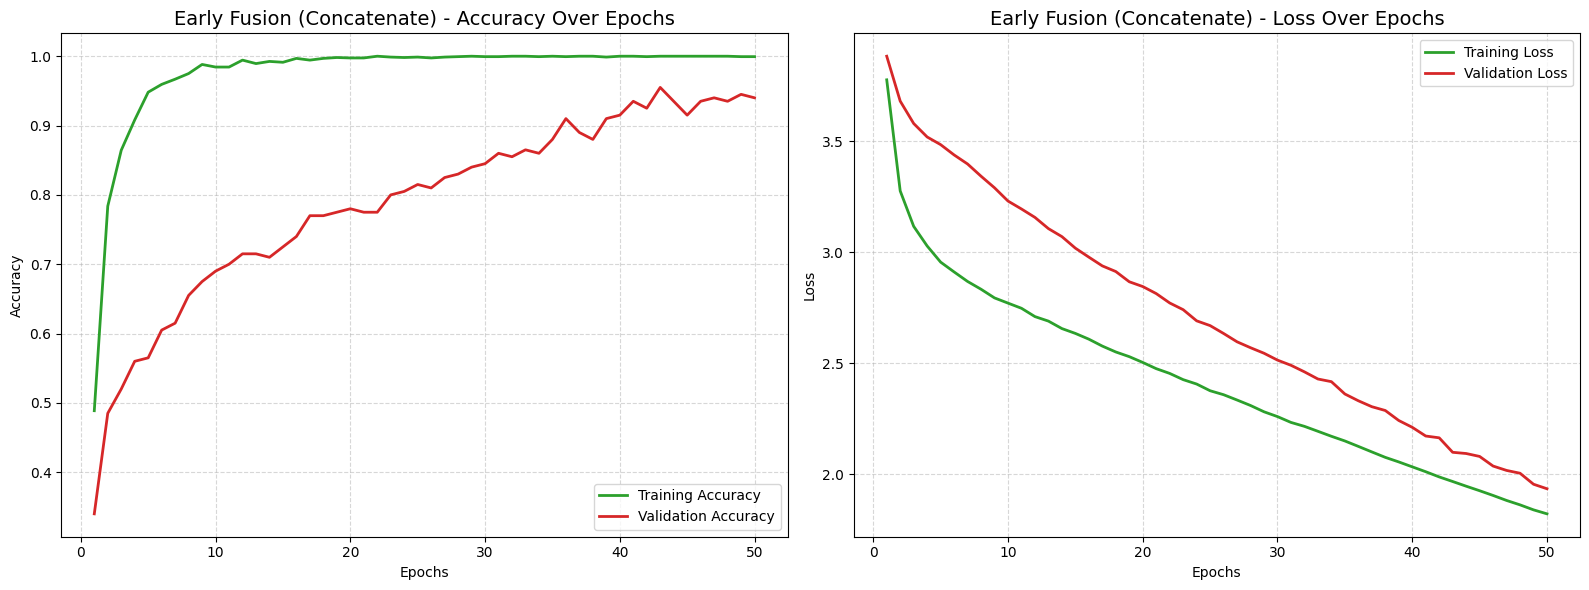

In [7]:
import matplotlib.pyplot as plt

def plot_simple_history(h):
    # استخراج البيانات من متغير history واحد
    acc = h.history['accuracy']
    val_acc = h.history['val_accuracy']
    loss = h.history['loss']
    val_loss = h.history['val_loss']
    
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(16, 6))

    # الرسمة الأولى: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#2ca02c', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#d62728', linewidth=2)
    plt.title('Early Fusion (Concatenate) - Accuracy Over Epochs', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.5)

    # الرسمة الثانية: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='#2ca02c', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#d62728', linewidth=2)
    plt.title('Early Fusion (Concatenate) - Loss Over Epochs', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# استدعاء الدالة بمتغير الـ history القديم بتاعك
plot_simple_history(history)

⌛ Generating predictions...


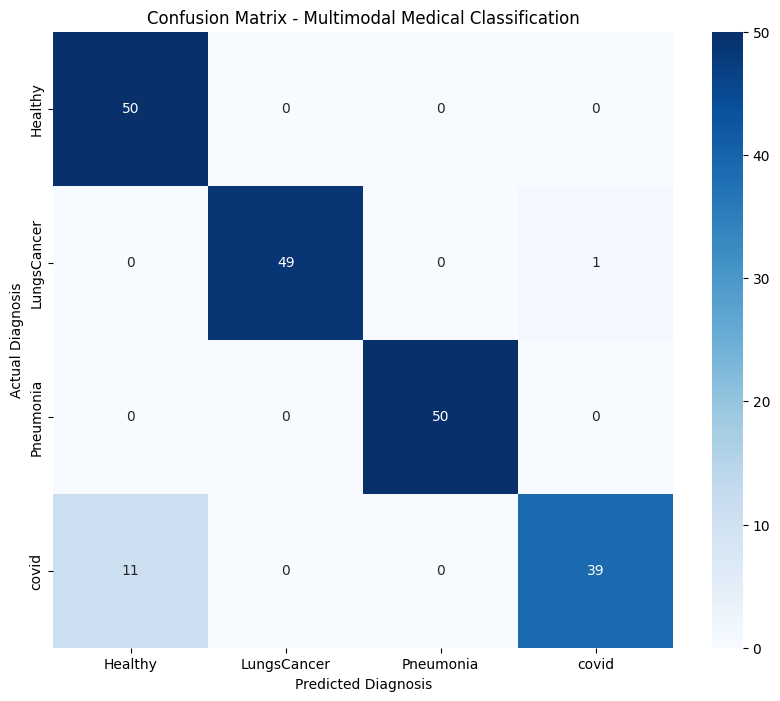


--- Classification Report ---
              precision    recall  f1-score   support

     Healthy       0.82      1.00      0.90        50
 LungsCancer       1.00      0.98      0.99        50
   Pneumonia       1.00      1.00      1.00        50
       covid       0.97      0.78      0.87        50

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.94       200
weighted avg       0.95      0.94      0.94       200



In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# تعريف أسامي الكلاسات بالترتيب اللي استخدمناه في الـ Generator
classes_in_folders = ["Healthy", "LungsCancer", "Pneumonia", "covid"]

# ... باقي الكود

# 1. تجهيز البيانات (تجميع الـ Labels الحقيقية من الـ Validation Set)
print("⌛ Generating predictions...")
y_true = []
y_pred = []

# بنمشي على الـ Validation dataset باتش باتش
for images, labels in val_ds:
    # التوقع (بندخل الـ 3 inputs للموديل)
    preds = model.predict(images, verbose=0)
    
    # تحويل الـ One-hot لـ Class index (0, 1, 2, 3)
    y_true.extend(np.argmax(labels, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 2. حساب الـ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 3. الرسم باستخدام Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes_in_folders, 
            yticklabels=classes_in_folders)

plt.title('Confusion Matrix - Multimodal Medical Classification')
plt.ylabel('Actual Diagnosis')
plt.xlabel('Predicted Diagnosis')
plt.show()

# 4. طبع تقرير مفصل (Precision, Recall, F1-Score)
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=classes_in_folders))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


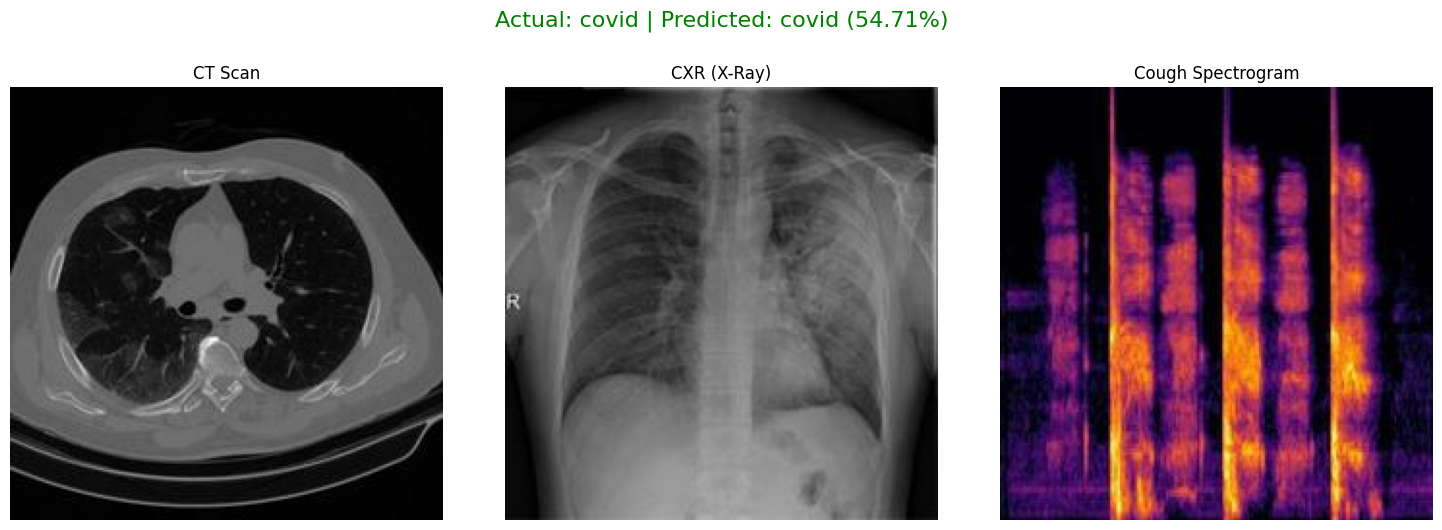

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. سحب "Batch" واحد من الـ Validation set
# images هنا عبارة عن tuple فيها (batch_ct, batch_cxr, batch_audio)
for images, labels in val_ds.take(1):
    # 2. عمل Prediction للباتش كله
    preds = model.predict(images)
    
    # 3. اختيار أول عينة في الباتش ده عشان نعرضها
    idx = 0 # ممكن تغير الرقم ده لغاية batch_size-1
    
    # فك الصور من الـ Tuple
    ct_img = images[0][idx]
    cxr_img = images[1][idx]
    audio_img = images[2][idx]
    
    # الحصول على التوقع والحقيقة
    true_label = classes_in_folders[np.argmax(labels[idx])]
    pred_label = classes_in_folders[np.argmax(preds[idx])]
    confidence = np.max(preds[idx]) * 100
    
    # 4. العرض المرئي (Visualization)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(ct_img)
    axes[0].set_title("CT Scan")
    axes[0].axis('off')
    
    axes[1].imshow(cxr_img)
    axes[1].set_title("CXR (X-Ray)")
    axes[1].axis('off')
    
    axes[2].imshow(audio_img)
    axes[2].set_title("Cough Spectrogram")
    axes[2].axis('off')
    
    color = 'green' if true_label == pred_label else 'red'
    plt.suptitle(f"Actual: {true_label} | Predicted: {pred_label} ({confidence:.2f}%)", 
                 fontsize=16, color=color, y=1.05)
    
    plt.tight_layout()
    plt.show()

# 9 Channels (as one input) Method

In [10]:
import os
from pathlib import Path

# The correct folder name from your directory list
output_root = "processed_dataset_split" 

def get_paths_and_labels_final(base_path, split):
    ct_p, cxr_p, aud_p, lbls = [], [], [], []
    classes = ["Healthy", "LungsCancer", "Pneumonia", "covid"]
    class_map = {cls: i for i, cls in enumerate(classes)}
    
    # We use 'valid' because that's usually the folder name in your split
    # If it fails, we will check if it's named 'validation'
    split_path = Path(base_path) / split
    
    # Check if 'Cough sound' or 'Audio' is used in this split
    # I will check both to be safe
    audio_folder = "Cough sound" if (split_path / "Cough sound").exists() else "Audio"

    for cls in classes:
        ct_folder = split_path / "CT" / cls
        if not ct_folder.exists(): continue
        
        for img_file in sorted(os.listdir(ct_folder)):
            if img_file.endswith('.jpg'):
                p_ct = str(split_path / "CT" / cls / img_file)
                p_cxr = str(split_path / "CXR" / cls / img_file)
                p_aud = str(split_path / audio_folder / cls / img_file)
                
                if os.path.exists(p_ct) and os.path.exists(p_cxr) and os.path.exists(p_aud):
                    ct_p.append(p_ct)
                    cxr_p.append(p_cxr)
                    aud_p.append(p_aud)
                    lbls.append(class_map[cls])
                    
    return ct_p, cxr_p, aud_p, lbls

# Extracting paths using the CORRECT root
train_ct, train_cxr, train_aud, train_labels = get_paths_and_labels_final(output_root, 'train')
val_ct, val_cxr, val_aud, val_labels = get_paths_and_labels_final(output_root, 'valid')
test_ct, test_cxr, test_aud, test_labels = get_paths_and_labels_final(output_root, 'test')

print(f"✅ Train samples: {len(train_ct)}")
print(f"✅ Valid samples: {len(val_ct)}")
print(f"✅ Test samples:  {len(test_ct)}")

✅ Train samples: 1600
✅ Valid samples: 200
✅ Test samples:  200


In [11]:
import tensorflow as tf

def process_9channel(p_ct, p_cxr, p_aud, label):
    def load_and_resize(p):
        img = tf.io.read_file(p)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = tf.image.resize(img, (224, 224))
        return img

    # تحميل الـ 3 صور (كل واحدة 3 قنوات)
    img1 = load_and_resize(p_ct)
    img2 = load_and_resize(p_cxr)
    img3 = load_and_resize(p_aud)
    
    # دمجهم في العمق (Depth) لعمل 9 قنوات
    combined = tf.concat([img1, img2, img3], axis=-1) # (224, 224, 9)
    
    # تحويل الـ Label لـ One-hot
    one_hot_label = tf.one_hot(label, depth=4)
    
    return combined, one_hot_label

# إنشاء الـ Datasets النهائية
train_ds_9ch = tf.data.Dataset.from_tensor_slices((train_ct, train_cxr, train_aud, train_labels))
train_ds_9ch = train_ds_9ch.shuffle(len(train_ct)).map(process_9channel).batch(32).prefetch(tf.data.AUTOTUNE)

val_ds_9ch = tf.data.Dataset.from_tensor_slices((val_ct, val_cxr, val_aud, val_labels))
val_ds_9ch = val_ds_9ch.map(process_9channel).batch(32).prefetch(tf.data.AUTOTUNE)

In [12]:
from tensorflow.keras import layers, models, optimizers

def build_9ch_multimodal_model():
    # 1. المدخل الأصلي (9 قنوات)
    main_input = layers.Input(shape=(224, 224, 9), name='MultiChannel_Input')

    # 2. طبقة الدمج (9 to 3)
    x = layers.Conv2D(3, (1, 1), padding='same', name='fusion_layer')(main_input)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # 3. الـ Backbone (ResNet50V2) - بنعرفه كـ Model منفصل الأول
    # بنسيب الـ input_shape الافتراضي (224, 224, 3) عشان يحمل الأوزان صح
    base_model = tf.keras.applications.ResNet50V2(
        include_top=False, 
        weights='imagenet', 
        input_shape=(224, 224, 3) 
    )
    base_model.trainable = False 

    # 4. الربط: نمرر مخرج الـ fusion_layer لـ base_model
    x_resnet = base_model(x)

    # 5. الرأس التصنيفي
    y = layers.GlobalAveragePooling2D()(x_resnet)
    y = layers.Dense(256, activation='relu')(y)
    y = layers.Dropout(0.5)(y)
    outputs = layers.Dense(4, activation='softmax')(y)

    model = models.Model(inputs=main_input, outputs=outputs)
    return model

# تنفيذ البناء والـ Compile
model_9ch = build_9ch_multimodal_model()

model_9ch.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_9ch.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MultiChannel_Input (InputLayer) │ (None, 224, 224, 9)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fusion_layer (Conv2D)           │ (None, 224, 224, 3)    │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 3)    │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,090,414 (91.90 MB)

 Trainable params: 525,608 (2.01 MB)

 Non-trainable params: 23,564,806 (89.89 MB)

In [13]:
history_9ch = model_9ch.fit(
    train_ds_9ch,
    validation_data=val_ds_9ch,
    epochs=20, # ابدأ بـ 20 وشوف النتيجة
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3)
    ]
)

Epoch 1/20


2026-04-06 04:02:10.048751: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 04:02:10.196140: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 297ms/step - accuracy: 0.3641 - loss: 1.4634 - val_accuracy: 0.6450 - val_loss: 0.8207 - learning_rate: 1.0000e-04
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.6660 - loss: 0.7705 - val_accuracy: 0.7200 - val_loss: 0.6232 - learning_rate: 1.0000e-04
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step - accuracy: 0.7827 - loss: 0.5260 - val_accuracy: 0.7950 - val_loss: 0.5329 - learning_rate: 1.0000e-04
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 194ms/step - accuracy: 0.7846 - loss: 0.5174 - val_accuracy: 0.8450 - val_loss: 0.4510 - learning_rate: 1.0000e-04
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 188ms/step - accuracy: 0.8059 - loss: 0.4679 - val_accuracy: 0.8750 - val_loss: 0.3992 - learning_rate: 1.0000e-04
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step - accuracy: 0.8557 - loss: 0.3947 - val_accuracy: 0.8600 - val_loss: 0.3743 - learning_rate: 1.0000e-04
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 181ms/step - accuracy: 0.8563 -

In [14]:
from tensorflow.keras import optimizers

# 1. فك تجميد الموديل بالكامل عشان الـ ResNet تتعلم
model_9ch.trainable = True

# 2. إعادة الـ Compile بـ Learning Rate صغير جداً (مهم جداً)
model_9ch.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. تشغيل التدريب (تأكد من الـ epochs والـ initial_epoch)
# إحنا دربنا 20 قبل كدة، فعايزين نوصل لـ 35 مثلاً
history_fine = model_9ch.fit(
    train_ds_9ch,
    validation_data=val_ds_9ch,
    epochs=35,           # العدد الكلي للـ Epochs اللي عايز توصله
    initial_epoch=20,    # هيبدأ يعد من بعد الـ 20 اللي خلصوا
    verbose=1            # عشان يظهر الـ Progress Bar إجباري
)

Epoch 21/35
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 290ms/step - accuracy: 0.9235 - loss: 0.1884 - val_accuracy: 0.9000 - val_loss: 0.2682
Epoch 22/35
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step - accuracy: 0.9293 - loss: 0.2050 - val_accuracy: 0.8900 - val_loss: 0.2702
Epoch 23/35
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 190ms/step - accuracy: 0.9278 - loss: 0.2024 - val_accuracy: 0.8900 - val_loss: 0.2711
Epoch 24/35
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 191ms/step - accuracy: 0.9186 - loss: 0.2066 - val_accuracy: 0.8900 - val_loss: 0.2699
Epoch 25/35
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 186ms/step - accuracy: 0.9314 - loss: 0.1914 - val_accuracy: 0.8900 - val_loss: 0.2707
Epoch 26/35
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 182ms/step - accuracy: 0.9074 - loss: 0.2126 - val_accuracy: 0.8900 - val_loss: 0.2695
Epoch 27/35
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 179ms/step - accuracy: 0.9457 - loss: 0.1793 - val_accuracy: 0.8950 - val_loss: 0.2693
Epoch 28/35
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 178ms/step - accuracy: 0.9113 - loss: 0.2211 - val_a

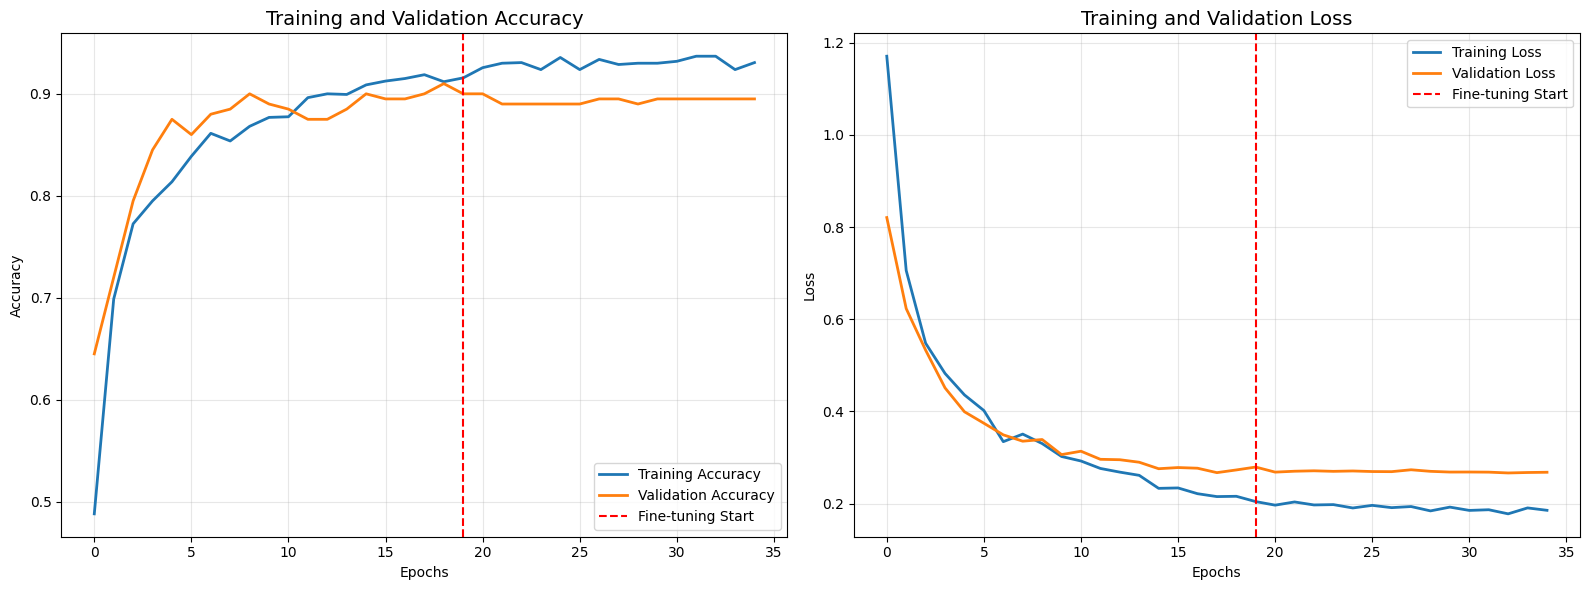

In [15]:
import matplotlib.pyplot as plt

def plot_full_history(h1, h2):
    # دمج بيانات التدريب من المرحلتين
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']
    
    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 6))

    # الرسمة الأولى: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)
    plt.axvline(x=19, color='r', linestyle='--', label='Fine-tuning Start') # خط فاصل عند epoch 20
    plt.title('Training and Validation Accuracy', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # الرسمة الثانية: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
    plt.axvline(x=19, color='r', linestyle='--', label='Fine-tuning Start')
    plt.title('Training and Validation Loss', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# استدعاء الدالة (تأكد إن h1 هو history المرحلة الأولى و h2 هو history_fine)
plot_full_history(history_9ch, history_fine)

⏳ Generating predictions for Validation Set...


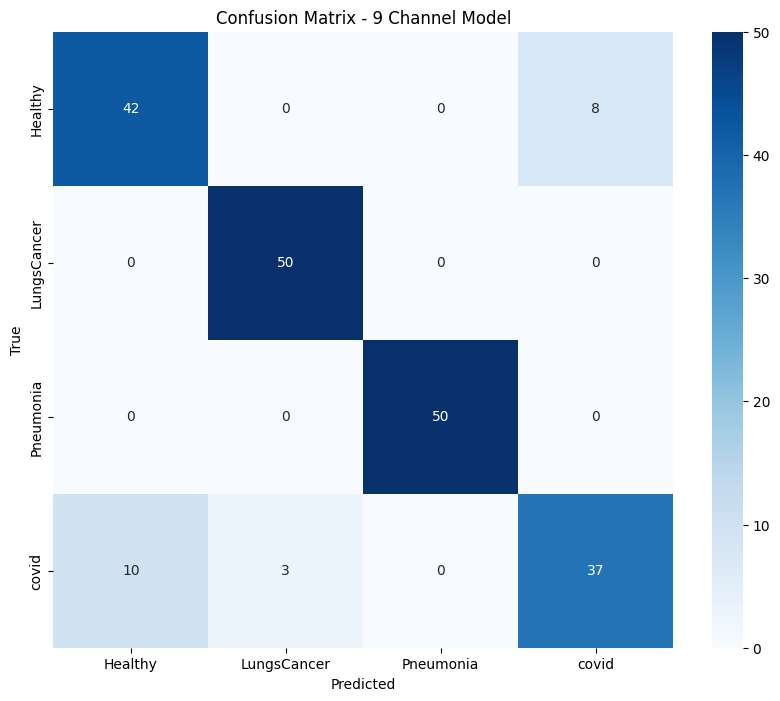


Detailed Classification Report:
              precision    recall  f1-score   support

     Healthy       0.81      0.84      0.82        50
 LungsCancer       0.94      1.00      0.97        50
   Pneumonia       1.00      1.00      1.00        50
       covid       0.82      0.74      0.78        50

    accuracy                           0.90       200
   macro avg       0.89      0.90      0.89       200
weighted avg       0.89      0.90      0.89       200



In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. توقع النتائج للـ Validation Set
y_pred = []
y_true = []

print("⏳ Generating predictions for Validation Set...")

for images, labels in val_ds_9ch:
    # التوقع للمجموعة (Batch)
    preds = model_9ch.predict(images, verbose=0)
    
    # تحويل الـ Softmax Output لأرقام كلاسات (0, 1, 2, 3)
    y_pred.extend(np.argmax(preds, axis=1))
    
    # تحويل الـ One-hot Labels لأرقام كلاسات
    y_true.extend(np.argmax(labels, axis=1))

# 2. تعريف أسماء الكلاسات بنفس الترتيب
classes = ["Healthy", "LungsCancer", "Pneumonia", "covid"]

# 3. حساب ورسم الـ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - 9 Channel Model')
plt.show()

# 4. تقرير الأداء التفصيلي (Precision, Recall, F1-score)
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

In [17]:
import glob
import os
from pathlib import Path

# 1. Correct Root
output_root = "processed_dataset_split"
split = "test"
base_path = Path(output_root) / split

# 2. Re-extract everything using Wildcards (**)
# This way we don't care about the exact folder name 'Cough sound'
test_ct = sorted(glob.glob(str(base_path / "CT/*/*.jpg")))
test_cxr = sorted(glob.glob(str(base_path / "CXR/*/*.jpg")))

# Look for ANY folder that might contain audio plots (using ** for recursion)
# This will find them whether the folder is 'Cough sound', 'Audio', or 'cough'
test_audio = sorted(glob.glob(str(base_path / "*" / "*" / "*.jpg")))
# Filter out CT and CXR from the general search to keep only Audio
test_audio = [p for p in test_audio if "CT" not in p and "CXR" not in p]

# 3. Final Alignment Check
# We only keep files that exist in all three (based on filename)
final_ct, final_cxr, final_aud, final_lbls = [], [], [], []
classes = ["Healthy", "LungsCancer", "Pneumonia", "covid"]
class_map = {cls: i for i, cls in enumerate(classes)}

for ct_path in test_ct:
    img_name = os.path.basename(ct_path)
    cls_name = ct_path.split('/')[-2] # Extract class from path
    
    # Construct potential matches
    match_cxr = [p for p in test_cxr if img_name in p and cls_name in p]
    match_aud = [p for p in test_audio if img_name in p and cls_name in p]
    
    if match_cxr and match_aud:
        final_ct.append(ct_path)
        final_cxr.append(match_cxr[0])
        final_aud.append(match_aud[0])
        final_lbls.append(class_map[cls_name])

# Update your variables for the Dataset
test_ct, test_cxr, test_audio, test_labels = final_ct, final_cxr, final_aud, final_lbls

# --- THE CHECK ---
print("--- Dataset Length Check ---")
print(f"Total CT scans:    {len(test_ct)}")
print(f"Total CXR images:  {len(test_cxr)}")
print(f"Total Audio plots: {len(test_audio)}")
print(f"Total Labels:      {len(test_labels)}")
print("----------------------------")

if len(test_ct) == 200:
    print("✅ PERFECT! Everything is aligned now.")

--- Dataset Length Check ---
Total CT scans:    200
Total CXR images:  200
Total Audio plots: 200
Total Labels:      200
----------------------------
✅ PERFECT! Everything is aligned now.


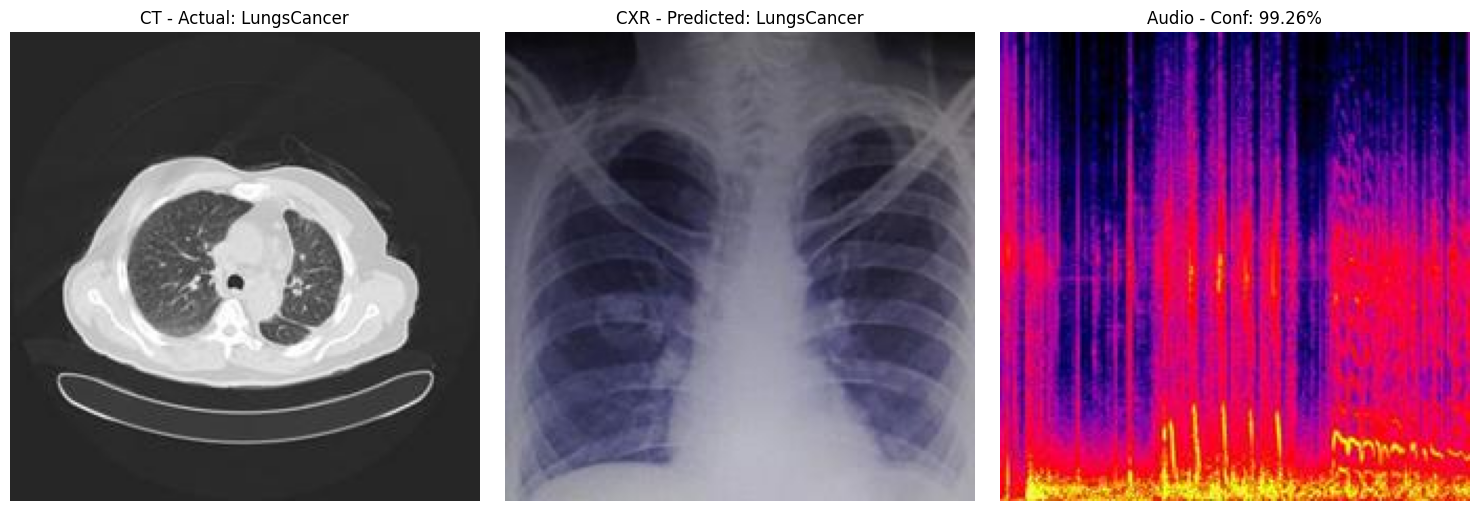

✅ Result: CORRECT! (LungsCancer)


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf

def predict_random_sample(model, ct_list, cxr_list, aud_list, labels_list):
    if len(ct_list) == 0:
        print("❌ Error: List is still empty. Run the extraction cell first.")
        return

    # 1. Pick a random index
    idx = random.randint(0, len(ct_list) - 1)
    classes = ["Healthy", "LungsCancer", "Pneumonia", "covid"]
    
    # 2. Extract specific paths for this sample
    p_ct = ct_list[idx]
    p_cxr = cxr_list[idx]
    p_aud = aud_list[idx]
    actual_idx = labels_list[idx]
    
    # 3. Process input using YOUR function's signature
    # Passing the 3 paths and a dummy label (0) separately
    image_9ch, _ = process_9channel(p_ct, p_cxr, p_aud, 0) 
    
    # 4. Model Prediction
    # Expand dims to (1, H, W, 9)
    prediction = model.predict(tf.expand_dims(image_9ch, axis=0), verbose=0)
    pred_idx = np.argmax(prediction)
    conf_score = np.max(prediction) * 100
    
    # 5. Visualization
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(plt.imread(p_ct))
    plt.title(f"CT - Actual: {classes[actual_idx]}")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(plt.imread(p_cxr))
    plt.title(f"CXR - Predicted: {classes[pred_idx]}")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(plt.imread(p_aud))
    plt.title(f"Audio - Conf: {conf_score:.2f}%")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    if pred_idx == actual_idx:
        print(f"✅ Result: CORRECT! ({classes[pred_idx]})")
    else:
        print(f"❌ Result: WRONG. (Pred: {classes[pred_idx]} | Actual: {classes[actual_idx]})")

# Use final_ lists to be 100% sure we have synchronized data
test_ct, test_cxr, test_audio, test_labels = final_ct, final_cxr, final_aud, final_lbls

# Run it
predict_random_sample(model_9ch, test_ct, test_cxr, test_audio, test_labels)

# Final Comparison between Two Methods

In [19]:
def process_early(p_ct, p_cxr, p_aud, label):
    # 1. Read images
    img_ct = tf.io.read_file(p_ct)
    img_ct = tf.image.decode_jpeg(img_ct, channels=3)
    img_ct = tf.image.resize(img_ct, [224, 224]) / 255.0
    
    img_cxr = tf.io.read_file(p_cxr)
    img_cxr = tf.image.decode_jpeg(img_cxr, channels=3)
    img_cxr = tf.image.resize(img_cxr, [224, 224]) / 255.0
    
    img_aud = tf.io.read_file(p_aud)
    img_aud = tf.image.decode_jpeg(img_aud, channels=3)
    img_aud = tf.image.resize(img_aud, [224, 224]) / 255.0
    
    # 2. Early Fusion (Horizontal Concatenation)
    # Check if you used tf.concat on axis 1 (width) or axis 0 (height)
    early_fused_image = tf.concat([img_ct, img_cxr, img_aud], axis=1) 
    
    return early_fused_image, label

⏳ Final Evaluation in progress... Please wait.


2026-04-06 04:08:21.387441: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 04:08:21.543636: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 04:08:21.677670: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


,Model,Accuracy,F1-Score,Recall,Precision
0,Multi-Input (Intermediate),0.940,0.940259,0.940,0.941712
1,9-Channel Stack (Early),0.865,0.864987,0.865,0.865050


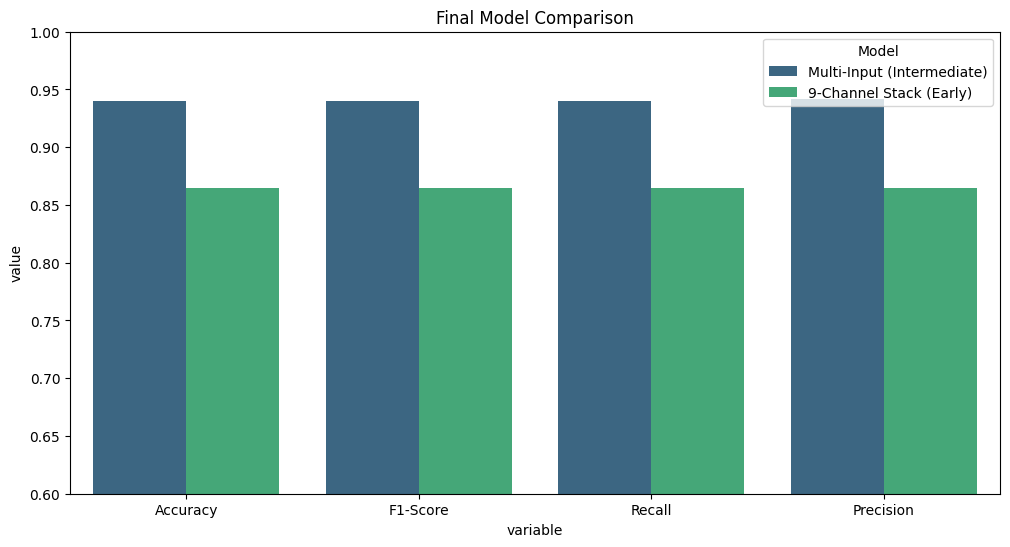

In [20]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

# 1. تعريف الدالة هنا احتياطياً لضمان عدم حدوث NameError
def process_early_final_check(p_ct, p_cxr, p_aud):
    def load_and_prep(path):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [224, 224]) / 255.0
        return tf.expand_dims(img, axis=0)
    return load_and_prep(p_ct), load_and_prep(p_cxr), load_and_prep(p_aud)

# 2. مصفوفات التوقعات
y_pred_early = []
y_pred_9ch = []

print("⏳ Final Evaluation in progress... Please wait.")

# 3. الـ Loop الشاملة
for i in range(len(test_ct)):
    # تقييم الموديل الأول (Intermediate Fusion)
    img_ct, img_cxr, img_aud = process_early_final_check(test_ct[i], test_cxr[i], test_audio[i])
    p_e = model.predict([img_ct, img_cxr, img_aud], verbose=0)
    y_pred_early.append(np.argmax(p_e))

    # تقييم الموديل الثاني (Early Fusion / 9-Channel)
    img_9, _ = process_9channel(test_ct[i], test_cxr[i], test_audio[i], 0)
    p_9 = model_9ch.predict(tf.expand_dims(img_9, axis=0), verbose=0)
    y_pred_9ch.append(np.argmax(p_9))

# 4. حساب وعرض النتائج
raw_metrics = {
    "Model": ["Multi-Input (Intermediate)", "9-Channel Stack (Early)"],
    "Accuracy": [accuracy_score(test_labels, y_pred_early), accuracy_score(test_labels, y_pred_9ch)],
    "F1-Score": [f1_score(test_labels, y_pred_early, average='weighted'), f1_score(test_labels, y_pred_9ch, average='weighted')],
    "Recall": [recall_score(test_labels, y_pred_early, average='weighted'), recall_score(test_labels, y_pred_9ch, average='weighted')],
    "Precision": [precision_score(test_labels, y_pred_early, average='weighted'), precision_score(test_labels, y_pred_9ch, average='weighted')]
}

final_df = pd.DataFrame(raw_metrics)
display(final_df)

# 5. الرسم البياني النهائي
plot_data = pd.melt(final_df, id_vars=['Model'], value_vars=['Accuracy', 'F1-Score', 'Recall', 'Precision'])
plt.figure(figsize=(12, 6))
sns.barplot(x='variable', y='value', hue='Model', data=plot_data, palette='viridis')
plt.ylim(0.6, 1.0)
plt.title("Final Model Comparison")
plt.show()